In [1]:
import os
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical

import imageio
from IPython.display import Image, display
from google.colab import drive

print("PyTorch version: " + torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Koristi se uređaj: {device}")

PyTorch version: 2.11.0+cu128
Koristi se uređaj: cuda


In [2]:
########################################################################################################################
# MONTIRANJE GOOGLE DRIVE-A
########################################################################################################################

drive.mount('/content/drive')

drive_results_folder = '/content/drive/MyDrive/CartPoleActorCritic_PyTorch'
if not os.path.exists(drive_results_folder):
    os.makedirs(drive_results_folder)
    print(f"Napravljen direktorijum za rezultate na Drive-u: {drive_results_folder}")

# Definisanje putanja
agent_path = os.path.join(drive_results_folder, "CartPoleActorCritic_agent.pth")
fig_path = os.path.join(drive_results_folder, "CartPoleActorCritic_training.png")
gif_path = os.path.join(drive_results_folder, "CartPoleActorCritic_demo.gif")

Mounted at /content/drive


In [3]:
########################################################################################################################
# ACTOR-CRITIC MREŽA
########################################################################################################################

class ActorCriticNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super(ActorCriticNetwork, self).__init__()

        self.fc1 = nn.Linear(state_size, 128)
        self.actor_fc = nn.Linear(128, action_size)
        self.critic_fc = nn.Linear(128, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        action_probs = F.softmax(self.actor_fc(x), dim=-1)
        state_value = self.critic_fc(x)
        return action_probs, state_value

In [4]:
########################################################################################################################
# ACTOR-CRITIC AGENT KLASA
########################################################################################################################

class ActorCriticAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size

        self.gamma = 0.99
        self.learning_rate = 0.005 # Malo viša stopa učenja je standard za A2C

        self.model = ActorCriticNetwork(state_size, action_size).to(device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)

        # Liste za pamćenje istorije unutar jedne epizode
        self.saved_log_probs = []
        self.state_values = []
        self.rewards = []

    def act(self, state):
        state_tensor = torch.FloatTensor(state).to(device)
        action_probs, state_value = self.model(state_tensor)

        m = Categorical(action_probs)
        action = m.sample()

        # Interno pamtimo podatke za učenje na kraju epizode
        self.saved_log_probs.append(m.log_prob(action))
        self.state_values.append(state_value)

        # Vraćamo samo akciju
        return action.item()

    def learn_episode(self):
        if not self.rewards:
            return

        # Računamo diskontovane nagrade unazad
        returns = []
        R = 0
        for r in self.rewards[::-1]:
            R = r + self.gamma * R
            returns.insert(0, R)

        returns = torch.tensor(returns).to(device)

        # Normalizacija nagrada - ključno za stabilnost Kritičara!
        returns = (returns - returns.mean()) / (returns.std() + 1e-9)

        policy_losses = []
        critic_losses = []

        for log_prob, value, R in zip(self.saved_log_probs, self.state_values, returns):
            advantage = R - value.item()

            policy_losses.append(-log_prob * advantage)
            critic_losses.append(F.smooth_l1_loss(value, torch.tensor([R]).to(device)))

        # Zbir grešaka (Kritičara množimo sa 0.5)
        loss = torch.stack(policy_losses).sum() + 0.5 * torch.stack(critic_losses).sum()

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Čišćenje lista za novu epizodu
        self.saved_log_probs.clear()
        self.state_values.clear()
        self.rewards.clear()

Započinjem obučavanje...


/tmp/ipykernel_1332/1944889619.py:58: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  critic_losses.append(F.smooth_l1_loss(value, torch.tensor([R]).to(device)))


Epizoda: 1/500 | Rezultat: 20
Epizoda: 2/500 | Rezultat: 27
Epizoda: 3/500 | Rezultat: 25
Epizoda: 4/500 | Rezultat: 10
Epizoda: 5/500 | Rezultat: 27
Epizoda: 6/500 | Rezultat: 13
Epizoda: 7/500 | Rezultat: 21
Epizoda: 8/500 | Rezultat: 25
Epizoda: 9/500 | Rezultat: 22
Epizoda: 10/500 | Rezultat: 13
Epizoda: 11/500 | Rezultat: 18
Epizoda: 12/500 | Rezultat: 54
Epizoda: 13/500 | Rezultat: 21
Epizoda: 14/500 | Rezultat: 12
Epizoda: 15/500 | Rezultat: 28
Epizoda: 16/500 | Rezultat: 60
Epizoda: 17/500 | Rezultat: 13
Epizoda: 18/500 | Rezultat: 36
Epizoda: 19/500 | Rezultat: 46
Epizoda: 20/500 | Rezultat: 47
Epizoda: 21/500 | Rezultat: 60
Epizoda: 22/500 | Rezultat: 45
Epizoda: 23/500 | Rezultat: 44
Epizoda: 24/500 | Rezultat: 25
Epizoda: 25/500 | Rezultat: 52
Epizoda: 26/500 | Rezultat: 27
Epizoda: 27/500 | Rezultat: 36
Epizoda: 28/500 | Rezultat: 96
Epizoda: 29/500 | Rezultat: 27
Epizoda: 30/500 | Rezultat: 106
Epizoda: 31/500 | Rezultat: 42
Epizoda: 32/500 | Rezultat: 37
Epizoda: 33/500 

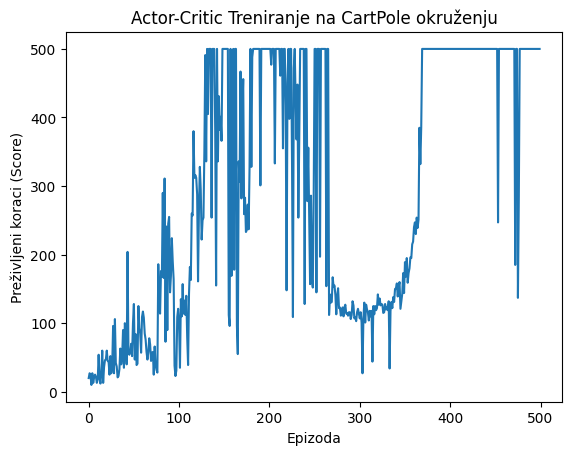

In [5]:
########################################################################################################################
# GLAVNA PETLJA ZA OBUČAVANJE
########################################################################################################################

env = gym.make('CartPole-v1')
state_size = int(env.observation_space.shape[0])
action_size = int(env.action_space.n)

agent = ActorCriticAgent(state_size, action_size)
episodes = 500

scores = []

print("Započinjem obučavanje...")
for e in range(episodes):
    state, info = env.reset()
    state = np.reshape(state, [1, state_size])

    time_steps = 0
    done = False

    while not done:
        # Sada dobijamo samo akciju
        action = agent.act(state)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Kažnjavamo ga jako za pad
        if terminated:
            reward = -10

        # Dodajemo nagradu u internu memoriju agenta
        agent.rewards.append(reward)

        state = np.reshape(next_state, [1, state_size])
        time_steps += 1

        if done:
            # Učimo tek na kraju cele epizode!
            agent.learn_episode()

            print(f"Epizoda: {e+1}/{episodes} | Rezultat: {time_steps}")
            scores.append(time_steps)
            break

torch.save(agent.model.state_dict(), agent_path)
print(f"Težine modela su uspešno sačuvane u fajl '{agent_path}'!")

plt.plot(scores)
plt.ylabel('Preživljeni koraci (Score)')
plt.xlabel('Epizoda')
plt.title('Actor-Critic Treniranje na CartPole okruženju')
plt.savefig(fig_path)
plt.show()

Obučeni model je uspešno učitan sa diska.
Pokrećem obučenog agenta i snimam frejmove...
Epizoda završena nakon 500 koraka. Generišem GIF animaciju...


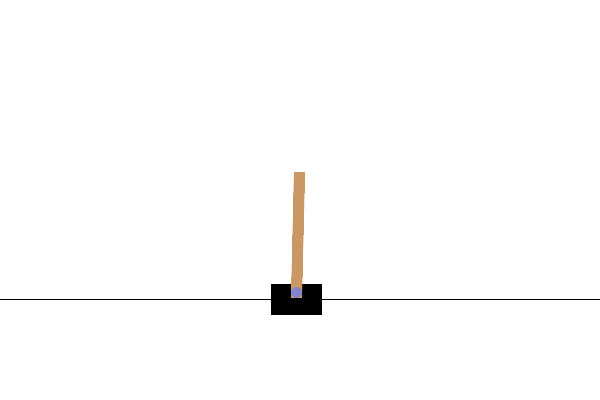

In [6]:
########################################################################################################################
# VIZUELIZACIJA RADA OBUČENOG AGENTA
########################################################################################################################

loaded_agent = ActorCriticAgent(state_size, action_size)
loaded_agent.model.load_state_dict(torch.load(agent_path, weights_only=True))
loaded_agent.model.eval()

print("Obučeni model je uspešno učitan sa diska.")

env_render = gym.make('CartPole-v1', render_mode='rgb_array')
state, info = env_render.reset()
state = np.reshape(state, [1, state_size])

frames = []
done = False
time_steps = 0

print("Pokrećem obučenog agenta i snimam frejmove...")

while not done:
    frames.append(env_render.render())

    state_tensor = torch.FloatTensor(state).to(device)
    with torch.no_grad():
        action_probs, _ = loaded_agent.model(state_tensor)
        # Za testiranje biramo akciju sa najvećom verovatnoćom (bez semplovanja)
        action = torch.argmax(action_probs).item()

    next_state, reward, terminated, truncated, info = env_render.step(action)
    done = terminated or truncated

    state = np.reshape(next_state, [1, state_size])
    time_steps += 1

env_render.close()

print(f"Epizoda završena nakon {time_steps} koraka. Generišem GIF animaciju...")
imageio.mimsave(gif_path, frames, duration=1000/30, loop=0)

# Prikazivanje GIF-a
display(Image(filename=gif_path))